In [57]:
import os
import pandas as pd
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [58]:
# Some basic variables
hartree_to_kj = 2625.5

# Orca Plotter

+ Specify Molecule
+ Visualize Results

In [59]:
molecule = 'o2'
molecule_path = str()
subfolders = []

for item in os.listdir('.'):
    if molecule in item:
        molecule_path = os.path.join(os.getcwd(), item)

print(f"Path to the molecule '{molecule}': {molecule_path}")
# Loop over all subfolders
for item in os.listdir(molecule_path):
    subfolders.append(os.path.join(molecule_path, item))

print(f"Subfolders found: {subfolders}")

Path to the molecule 'o2': /home/lme/practical_course/practical_course_bachelor/o2
Subfolders found: ['/home/lme/practical_course/practical_course_bachelor/o2/b3lyp_6_311_g_dp', '/home/lme/practical_course/practical_course_bachelor/o2/mp2_6_311_g_dp', '/home/lme/practical_course/practical_course_bachelor/o2/hf_6_311_g_dp']


### Frequencies:

Workflow:

+ Open up all the subfolders
+ Open the `orca.out` file in each subfolder
+ Extract the frequencies from the `orca.out` file
+ Display them for comparison

In [60]:
# Search for the 'molecule.out' file in each subfolder

molecule_out_files = []
for subfolder in subfolders: 
    molecule_out_file = os.path.join(subfolder, molecule.lower() + '.out')
    molecule_out_files.append(molecule_out_file)

# Loop through all the files and open them
total_frequencies = []
for molecule_out_file in molecule_out_files:
    if os.path.exists(molecule_out_file):
        with open(molecule_out_file, 'r') as file:
            output = file.read()
            # Seach for VIBRATIONAL FREQUENCIES
            frequencies = pd.DataFrame(columns=['Mode', 'Frequency (cm-1)'])
            frequencies_block = []
            switch = False
            for line in output.splitlines():
                if 'VIBRATIONAL FREQUENCIES' in line:
                    switch = True

                if switch:
                    frequencies_block.append(line.strip())

                if 'NORMAL MODES' in line:
                    switch = False
            
            # Loop through the frequencies block and save the frequencies 
            for line in frequencies_block:
                # If line starts with number, it is a frequency line
                if line and line[0].isdigit():
                    parts = line.split()
                    mode = parts[0]
                    frequency_value = parts[1]
                    data = pd.DataFrame([[mode, frequency_value]], columns=['Mode', 'Frequency (cm-1)'])
                    frequencies = pd.concat([frequencies, data], ignore_index=True)

            total_frequencies.append(frequencies)
            print(f"Frequencies for {molecule_out_file}:")
            display(HTML(frequencies.to_html(index=False)))

            

Frequencies for /home/lme/practical_course/practical_course_bachelor/o2/b3lyp_6_311_g_dp/o2.out:


Mode,Frequency (cm-1)
0:,0.00
1:,0.00
2:,0.00
3:,0.00
4:,0.00
5:,1640.27


Frequencies for /home/lme/practical_course/practical_course_bachelor/o2/mp2_6_311_g_dp/o2.out:


Mode,Frequency (cm-1)
0:,0.00
1:,0.00
2:,0.00
3:,0.00
4:,0.00
5:,1451.21


Frequencies for /home/lme/practical_course/practical_course_bachelor/o2/hf_6_311_g_dp/o2.out:


Mode,Frequency (cm-1)
0:,0.00
1:,0.00
2:,0.00
3:,0.00
4:,0.00
5:,2000.05


# Bond Scan and Force Constants

+ Get Scan Data
+ plot the bond length vs. energy
+ Fit Quadratic Function
+ Calculate Force constants and frequencies

In [61]:
molecule = 'co_'
molecule_path = str()
subfolders = []

for item in os.listdir('.'):
    if molecule in item:
        molecule_path = os.path.join(os.getcwd(), item)
# Loop over all subfolders
for item in os.listdir(molecule_path):
    subfolders.append(os.path.join(molecule_path, item))

# Search for subfolder containing 'bond_scan'
bond_scan_subfolder = ''
for subfolder in subfolders:
    if 'bond_scan' in subfolder:
        bond_scan_subfolder = subfolder
        break

# Open up the subfolder and search for 'molecule_scan.relaxscanmp2.dat'

bond_scan_file = os.path.join(bond_scan_subfolder, molecule.lower() + 'scan.relaxscanmp2.dat')

scan_data = pd.DataFrame(columns=['Bond Length (Å)', 'Energy (Hartree)'])
if os.path.exists(bond_scan_file):
    
    with open(bond_scan_file, 'r') as file:
        bond_scan_data = file.read()
        # Split the data into lines
        lines = bond_scan_data.splitlines()
        # Split lines at whitespace and save the data
        for line in lines:
            if line.strip():  # Check if the line is not empty
                parts = line.split()
                if len(parts) == 2:  # Ensure there are exactly two parts
                    bond_length = float(parts[0])
                    energy = float(parts[1])
                    scan_data = pd.concat([scan_data, pd.DataFrame([[bond_length, energy]], columns=['Bond Length (Å)', 'Energy (Hartree)'])], ignore_index=True)


/tmp/ipykernel_1216/3131774405.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  scan_data = pd.concat([scan_data, pd.DataFrame([[bond_length, energy]], columns=['Bond Length (Å)', 'Energy (Hartree)'])], ignore_index=True)


------------------------------------------------------------
Minimum Energy: -113.07475341 Hartree at Bond Length: 1.13768844 Å
Fitted parameters: a=2.1365810498135263, b=-4.869249002950344, c=-110.30051743106316


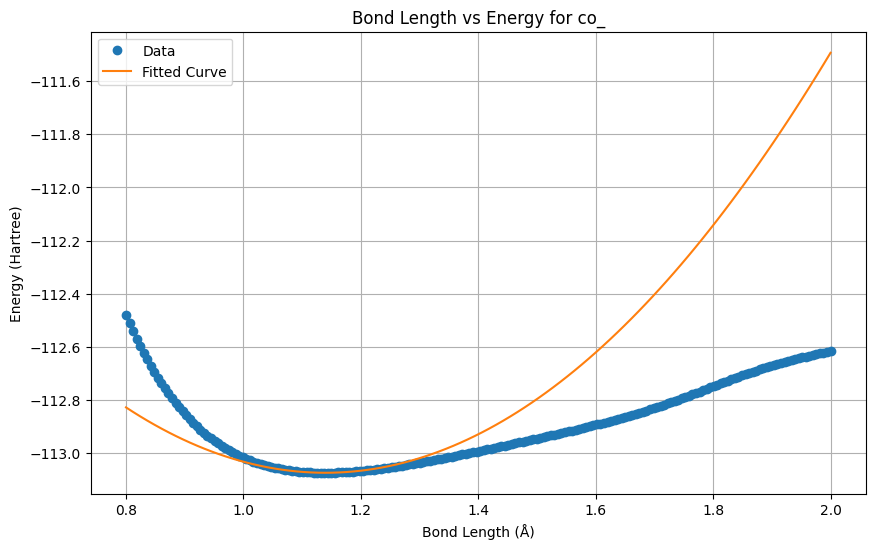

In [62]:
# Get Position and Minimum Energy
min_energy = scan_data['Energy (Hartree)'].min()
min_energy_position = scan_data.loc[scan_data['Energy (Hartree)'] == min_energy, 'Bond Length (Å)'].values[0]

print('--'*30)
print(f"Minimum Energy: {min_energy} Hartree at Bond Length: {min_energy_position} Å")

from scipy.optimize import curve_fit

def quadratic_function(x, a, b, c):
    return a * x**2 + b * x + c

# Select n points around the minimum energy
n = 5
x_fit = scan_data['Bond Length (Å)'].values
y_fit = scan_data['Energy (Hartree)'].values
min_index = scan_data['Energy (Hartree)'].idxmin()
start_index = max(0, min_index - n)
end_index = min(len(scan_data), min_index + n + 1)

x_fit = x_fit[start_index:end_index]
y_fit = y_fit[start_index:end_index]

# Fit the quadratic function to the data
params, covariance = curve_fit(quadratic_function, x_fit, y_fit)

a, b, c = params
print(f"Fitted parameters: a={a}, b={b}, c={c}")

x_fit = np.linspace(scan_data['Bond Length (Å)'].min(), scan_data['Bond Length (Å)'].max(), 100)
y_fit = quadratic_function(x_fit, *params)

# Plot the data and the fitted curve
plt.figure(figsize=(10, 6))
plt.plot(scan_data['Bond Length (Å)'], scan_data['Energy (Hartree)'], 'o', label='Data')
plt.plot(x_fit, y_fit, '-', label='Fitted Curve')
plt.xlabel('Bond Length (Å)')
plt.ylabel('Energy (Hartree)')
plt.title(f'Bond Length vs Energy for {molecule}')
plt.legend()
plt.grid()
plt.show()